(sec:feature-extraction)=
# 画像特徴量の抽出

In [ ]:
"""
下準備のコード
"""

import os
import random
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.exceptions import ConvergenceWarning

# 実験に用いるデータ数
n_images_per_char = 200

# 一部の警告を無視
warnings.simplefilter('ignore', FutureWarning)
warnings.simplefilter('ignore', ConvergenceWarning)

# シードの固定
random.seed(31415)
np.random.seed(31415)

# グラフの設定
rc = {'figure.dpi': 150}
sns.set_theme(style='white', palette='colorblind', rc=rc)

# 結果を格納しておくDataFrame
result_df = pd.DataFrame(
    {
        'Method': pd.Series([], dtype='string'),
        'Accuracy': pd.Series([], dtype='float64'),
        'Phase': pd.Series([], dtype='string'),
    }
)

今回からは数字ではなく「ひらがな」のデータセットを用いて、より複雑な識別問題に取り組む。

データセットは国立国会図書館の[NDLラボ](https://lab.ndl.go.jp/)が公開している文字画像データセットを使用する。

- 文字画像データセット: <https://github.com/ndl-lab/hiragana_mojigazo>

実際のデータセットは、以下のURLにホストされているので、ここからダウンロードする。

**文字画像データセット(平仮名73文字版) (zip形式)** 

- <http://lab.ndl.go.jp/dataset/hiragana73.zip>

In [ ]:
"""
平仮名73文字データセットの準備
"""

import zipfile

import requests

url = 'http://lab.ndl.go.jp/dataset/hiragana73.zip'
filename = os.path.basename(url)

# HTTPリクエストを送ってデータサイズを取得
r = requests.get(url, stream=True)
total_size = int(r.headers.get('content-length', 0))
chunk_size = 65535

# "hiragana73"フォルダが存在し、その中身が空でないことを確認
if not os.path.exists('./hiragana73') or len(os.listdir('./hiragana73')) == 0:
    # 実際のファイルのダウンロード
    pbar = tqdm(total=total_size, unit='B', unit_scale=True)
    with open(filename, 'wb') as f:
        for data in r.iter_content(chunk_size):
            f.write(data)
            pbar.update(chunk_size)

    # ダウンロードが完了したらZIPを展開する
    with zipfile.ZipFile(filename, 'r') as f:
        f.extractall()

## データセットの前処理

このデータセットは濁音、半濁音を含むひらがな73文字に対して、そのUnicode値のフォルダの中に、48×48の画像がPNG形式で保存されている。

各ひらがなのUnicode値を調べるには、`ord`関数を用いてUnicode値に変換した後に、それを`hex`関数を用いて16進数表記の文字列に変換すれば良い。

一例として「あ」であれば、以下のようにUnicode値を得ることができる。

In [ ]:
char_a = 'あ'
hex_a = hex(ord(char_a))
print(f"Unicode of '{char_a:s}' is '{hex_a:s}'")

Unicode of 'あ' is '0x3042'


逆に、あいうえお順で文字を取得したければ、「あ」に対応するUnicode値である`0x3042`からスタートして、1ずつ値を上げていきながら、その数字を`chr`関数を用いて文字に変換すれば良い。

なお、16進数の文字列を整数に直したいときには、`int(hex_a)`と単に文字列を渡すだけではダメで、第2引数に何進数の数字なのかを与えて `int(hex_a, 16)` のようにする必要があることに注意すること。

上記のひらがなデータセットは「ゃ」や「っ」などの小文字を含まない73文字から構成されているが、「あ」から「ん」までは、小文字を含め82文字なので、これを列挙してみる。

In [ ]:
for i in range(82):
    print(chr(int(hex_a, 16) + i), end='')
    if (i + 1) % 10 == 0:
        print()

あぃいぅうぇえぉおか
がきぎくぐけげこごさ
ざしじすずせぜそぞた
だちぢっつづてでとど
なにぬねのはばぱひび
ぴふぶぷへべぺほぼぽ
まみむめもゃやゅゆょ
よらりるれろゎわゐゑ
をん

ひらがなデータセットのフォルダ名は16進数を表わす`0x`の代わりに`U`が接頭辞になっているので、フォルダ名の`U`を`0x`に置換して、どの文字がデータセットに含まれているかをチェックしてみる。

In [ ]:
# サブフォルダの数を調べる
dirname = 'hiragana73'
folders = sorted([d for d in os.listdir(dirname)])
print(f'There are {len(folders):d} folders in "{dirname:s}".')

# フォルダに対応する文字を列挙
for i, d in enumerate(folders):
    x = d.replace('U', '0x')
    print(chr(int(x, 16)), end='')
    if (i + 1) % 10 == 0:
        print()

There are 73 folders in "hiragana73".
あいうえおかがきぎく
ぐけげこごさざしじす
ずせぜそぞただちぢつ
づてでとどなにぬねの
はばぱひびぴふぶぷへ
べぺほぼぽまみむめも
やゆよらりるれろわゐ
ゑをん

なお、本データセットでは各文字に対して以下の表に書かれた個数ずつ画像が含まれており、文字によって画像数に多少の偏りがあることが分かる。

In [ ]:
import numpy as np
import pandas as pd

chars = [chr(int(d.replace('U', '0x'), 16)) for d in folders]
dir_paths = [os.path.join(dirname, d) for d in folders]
num_images = [len(os.listdir(d)) for d in dir_paths]

df = pd.DataFrame([(c, n) for c, n in zip(chars, num_images)])
sub_dfs = [df[i : i + 10].reset_index(drop=True) for i in range(0, len(df.index), 10)]
df = pd.concat(sub_dfs, axis=1).fillna('')

df.index = [i for i in range(len(df.index))]
df.columns = [j for j in range(len(df.columns))]


def custom_style(df):
    index = df.index
    columns = df.columns
    styles = []
    for i in range(len(index)):
        s = []
        for j in range(len(columns)):
            if columns[j] % 2 == 0:
                s.append('font-weight: bold;')
            else:
                s.append(None)
        styles.append(s)

    return np.array(styles, dtype='object')


df.style.format(precision=0).format_index('', axis=1).format_index('', axis=0).apply(custom_style, axis=None)

,,,,,,,,,,,,,,,,
,あ,1208,ぐ,1043,ず,1046,づ,1080,は,1247,べ,1109,や,1285,ゑ,1030
,い,1122,け,1155,せ,1165,て,1213,ば,1105,ぺ,268,ゆ,1282,を,1254
,う,1148,げ,1058,ぜ,1115,で,1178,ぱ,262,ほ,1115,よ,1166,ん,1285
,え,1077,こ,1115,そ,1285,と,1184,ひ,1074,ぼ,1044,ら,1114,,
,お,1283,ご,1078,ぞ,1066,ど,1134,び,1045,ぽ,261,り,1244,,
,か,1259,さ,1261,た,1285,な,1233,ぴ,126,ま,1285,る,1190,,
,が,1200,ざ,1070,だ,1116,に,1260,ふ,1285,み,1142,れ,1238,,
,き,1121,し,1285,ち,1052,ぬ,1093,ぶ,1149,む,1058,ろ,1069,,
,ぎ,1091,じ,1099,ぢ,1132,ね,1126,ぷ,112,め,1233,わ,1283,,
,く,1266,す,1282,つ,1142,の,1160,へ,1114,も,1187,ゐ,1053,,


In [ ]:
# | label: n_images_per_char
print(n_images_per_char)

200


この表が示すとおり、各文字について、約1000の画像が含まれていることが確認できる。ただし、半濁音のひらがなは全体的に少なめで100-300程度となっている。

### 分類用のデータ加工

MNISTでは手書き文字の画像が28x28=784次元ベクトル、ラベルが10種類の数字のいずれかを表わす0-9の数字であり、これらのデータを`scikit-learn`の`fetch_openml`から取得することができた。

このようなデータをひらがなデータセットに対して自前で作成しよう。今回のデータセットは、
- 濁音や半濁音、小文字を含まないひらがな48文字を扱う
- 各文字の画像をランダムに![](#n_images_per_char)枚取り出す
- 分類の難易度を上げるため、画像をランダムに回転したり、拡大縮小したりする
という条件の下で作成する。

In [ ]:
# 今回取り扱う平仮名のリスト
chars = 'あいうえおかきくけこさしすせそたちつてとなにぬねのはひふへほまみむめもやゆよらりるれろわゐゑをん'
n_chars = len(chars)
char2num = {c: i for i, c in enumerate(chars)}
print(f'We have {n_chars} hiragana characters.')

We have 48 hiragana characters.


In [ ]:
import cv2

# 読み込み画像の総数
n_total = n_images_per_char * n_chars

# 画像の読み取り
X = []  # 画像データ
y = []  # ラベルデータ
pbar = tqdm(total=n_total)
for c in chars:
    # 文字に対する数字を計算
    num = char2num[c]
    char_dir = os.path.join(dirname, f'U{ord(c):04X}')

    # 画像の読み込み
    image_files = [os.path.join(char_dir, f) for f in os.listdir(char_dir)]
    image_files = [f for f in image_files if f.endswith('.png')]

    image_files = np.random.choice(image_files, n_images_per_char, replace=False)
    for f in image_files:
        # グレースケールで画像を読み込む
        image = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise OSError(f'Failed to load image: {f:s}')

        # ランダム輝度変更
        factor = np.random.uniform(0.9, 1.1)
        image = (((image / 255.0) ** factor) * 255.0).astype('uint8')

        # データのランダム回転、ランダムスケール
        height, width = image.shape
        center = (width // 2, height // 2)
        scale = np.random.uniform(0.8, 1.1)
        angle = np.random.uniform(-60, 60)
        trans = cv2.getRotationMatrix2D(center, angle, scale)
        image = cv2.warpAffine(image, trans, (width, height), borderMode=cv2.BORDER_REPLICATE)

        # ランダムノイズを付加
        image = (image / 255.0).astype('float32')
        image = np.clip(image + np.random.normal(0.0, 0.02, size=image.shape), 0.0, 1.0)
        image = (image * 255.0).astype('uint8')

        X.append(image.flatten())
        y.append(num)

        pbar.update(1)

X = np.stack(X, axis=0)
y = np.stack(y, axis=0)
pbar.close()

  0%|          | 0/9600 [00:00<?, ?it/s]

データセットの作成が終了したら、8割の画像を訓練画像、残りの2割の画像をテスト画像として振り分けておく。以下のコードの `stratify=y` は、各文字について、訓練画像とテスト画像が同じ割合となるように分割するためのオプションである。

In [ ]:
from sklearn.model_selection import train_test_split

X, X_test, y, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, stratify=y)

print(f'#train: {len(X)}')
print(f' #test: {len(X_test)}')

#train: 7680
 #test: 1920


データセットの先頭数枚の画像は次のようになっている。

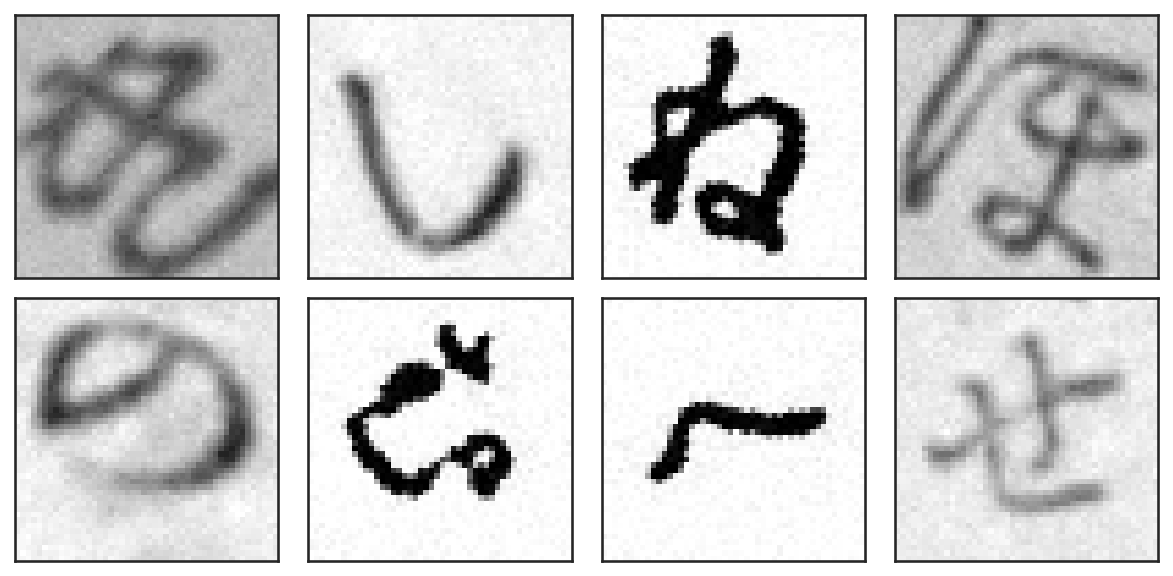

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8, 4))
gs = GridSpec(2, 4, figure=fig)

for i in range(8):
    ax = plt.subplot(gs[i])
    img = X[i].reshape((48, 48))
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

::::{admonition} 問
:class: question

データセットの作成では、`cv2.getRotationMatrix2D(center, angle, scale)`が返す2×3の行列を`cv2.warpAffine`に渡している。この行列を、回転角$\theta$、拡大率$s$、回転中心$\mathbf{c} = (c_x, c_y)^\top$を用いて書き下せ。

また、この変換が「回転中心を原点に移す平行移動」「原点まわりの回転と拡大縮小」「原点を元の位置に戻す平行移動」の3つの合成として表せることを、同次座標を用いた3×3の行列の積として示せ。

::::

## ベースライン: 画像をそのまま入力する

特徴量抽出の効果を測るためには、比較の基準が必要である。まずは、MNISTの時と同様に、画像をそのままベクトルとして分類器に与える方法をベースラインとして試してみる。この時、[scikit-learnの節](#sec:scikit-learn)で紹介したように、予め入力データの輝度を正規化する処理である`StandardScaler`を使用する。

ただし、従来の`LinearSVC`は学習がやや低速であるので、今回はミニバッチにより効率的に学習が可能な`SGDClassifier`を代わりに用いる。このクラスは、内部でデータセットの一部だけミニバッチとして分類器のパラメータ更新に用いる**確率的勾配降下法** (SGD=Stochastic Gradient Descent)により学習を行う。

`SGDClassifier`はパラメータに`loss="hinge"`を渡すと、内部では線形SVMをモデルに使用する。本パラメータは初期値が`"hinge"`であるが、以下に示すソースコードでは、明示的にパラメータを指定する。

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

clf = make_pipeline(
    StandardScaler(),
    SGDClassifier(loss='hinge'),
)
clf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('sgdclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](48,)","[ 0, 1, 2,...,45,46,47]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2304
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [ ]:
# 識別精度の確認
acc_train = clf.score(X, y)
acc_test = clf.score(X_test, y_test)

In [ ]:
# | label: naive_acc_train
result_df.loc[len(result_df), :] = ['Image', acc_train, 'Train']
print('%.2f' % (acc_train * 100.0))

75.36


In [ ]:
# | label: naive_acc_test
result_df.loc[len(result_df), :] = ['Image', acc_test, 'Test']
print('%.2f' % (acc_test * 100.0))

61.09


**結果: 画像をそのまま入力**

- 訓練時精度: ![](#naive_acc_train)%
- 評価時精度: ![](#naive_acc_test)%

このように、今回は分類問題の難易度が上がっており、SVMを用いても十分な精度が得られていないことが分かる。これには画像を扱う上で次のような問題が考えられる。

- 単に画像をベクトルとして扱うのは、(特に入力画像が大きい場合には)計算効率の観点からも好ましくない
- データセット中の画像上で文字の大きさや向きが揃っていない

これらの問題を解決すべく、以下では、文字の向きや大きさに依存しづらく、画像情報よりも低次かつ有意な特徴を取り出して、その特徴を元に分類器を学習する方法を紹介する。

## 主成分分析による次元圧縮

まずは、学習の効率化を図るために、前項、[次元削減](#sec:data-visualization)で紹介した主成分分析を用いて、画像データを低次元ベクトルに変換する。

`make_pipeline`を用いた分類器の定義において、`StandardScaler`の前に`PCA`による次元削減を追加する。

In [ ]:
from sklearn.decomposition import PCA

clf = make_pipeline(
    PCA(n_components=128),
    StandardScaler(),
    SGDClassifier(loss='hinge'),
)
clf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pca', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](48,)","[ 0, 1, 2,...,45,46,47]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2304
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",128
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and

In [ ]:
# 識別精度の確認
acc_train = clf.score(X, y)
acc_test = clf.score(X_test, y_test)

In [ ]:
# | label: pca_acc_train
result_df.loc[len(result_df), :] = ['PCA', acc_train, 'Train']
print('%.2f' % (acc_train * 100.0))

60.26


In [ ]:
# | label: pca_acc_test
result_df.loc[len(result_df), :] = ['PCA', acc_test, 'Test']
print('%.2f' % (acc_test * 100.0))

42.55


**結果: 主成分分析による次元圧縮**

- 訓練時精度: ![](#pca_acc_train)%
- 評価時精度: ![](#pca_acc_test)%

PCAによる次元削減を用いると、画像の中から顕著な特徴が抜き出されるものの、若干情報量としては減少してしまうため、単純に適用するだけでは精度が低下する。一方、画像を低次元ベクトルに置き換えたことで、学習に要する時間は大幅に削減される。

::::{admonition} 問
:class: question

`PCA(n_components=128)`の`n_components`を16, 32, 64, 256などに変えて、評価時の識別精度がどのように変化するかを調べよ。

また、`PCA`の`explained_variance_ratio_`の累積和を求め、元のデータの分散の90%を説明するには何次元必要かを確認した上で、それと識別精度の関係について考察せよ。

::::

## Local Binary Pattern (LBP)

Local Binary Pattern (LBP)は、とある画素を中心とした3x3の領域について、中心画素と周りの画素の輝度の大小関係を数値化する手法である {cite}`ojala1996comparative`。

画素の輝度の大小関係を数値化するということは、画像全体が明るくなったり、暗くなったりしても値がほとんど変化しない、ということであり、LBPは画像輝度の変化に頑健な特徴と言える。

LBPの計算を理解するための一例として、とある中心画素周辺の画素値が以下のようになっている場合を考えよう。

In [ ]:
def draw_frame(problem, fig, ax):
    mask = (problem == 0).astype('float32')
    frame = []
    ax.set_xticks(np.arange(0, 9))
    ax.set_yticks(np.arange(0, 9))
    ax.set_xticklabels(np.arange(1, 10))
    ax.set_yticklabels(np.arange(1, 10))

    ax.set_xticks(np.arange(1, 10) - 0.5, minor=True)
    ax.set_yticks(np.arange(1, 10) - 0.5, minor=True)
    ax.set_xticks(np.arange(3, 10, 3) - 0.5)
    ax.set_yticks(np.arange(3, 10, 3) - 0.5)

    ims = plt.imshow(mask * 0.2, cmap='Blues', vmin=0.0, vmax=1.0)
    frame.append(ims)
    for (i, j), z in np.ndenumerate(problem):
        txt = ax.text(j, i, f'{z:d}', ha='center', va='center', color='k', fontsize=15)
        frame.append(txt)

    ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
    ax.grid(which='major', color='k', linestyle='-', linewidth=1.0)

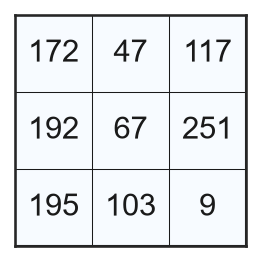

In [ ]:
rng = np.random.RandomState(0)
m = rng.randint(0, 256, size=(3, 3))
fig, ax = plt.subplots(figsize=(2, 2))
draw_frame(m, fig, ax)

このとき、周囲の8画素について中心画素以上の輝度を持つものを1、小さいものを0に置き換える。

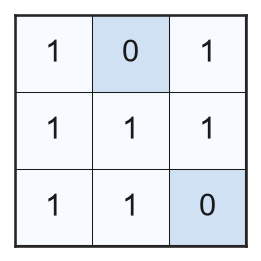

In [ ]:
c = m[1, 1]
b = (m >= c).astype('int32')
fig, ax = plt.subplots(figsize=(2, 2))
draw_frame(b, fig, ax)

この周囲の8画素に割り当てられた0, 1のパターンが8ビットの符号なし整数であると考えて数値を求める。この際、以下のような時計回りに2のべき乗が並んだ画像を用いる。

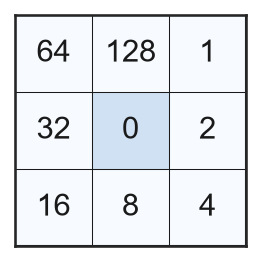

In [ ]:
p = 2 ** np.array([[6, 7, 0], [5, 0, 1], [4, 3, 2]])
p[1, 1] = 0

fig, ax = plt.subplots(figsize=(2, 2))
draw_frame(p, fig, ax)

In [ ]:
# | label: lbp_val
print(np.sum(b * p))

123


すると、上記の3x3の領域に対しては、LBPの値として **![](#lbp_val)** が求まる。

この計算を先ほどと同様にデータセットの先頭画像の各画素に対して計算すると、LBP画像は次のようになる。

In [ ]:
img = X[0].reshape((48, 48))

# 輪郭の画素では計算できないので、画像を1画素分広げる
img = np.pad(img, (1, 1), mode='edge')

# 各画素のLBPを計算
lbp_img = np.zeros_like(img).astype('uint8')
for iy in range(1, img.shape[0] - 1):
    for ix in range(1, img.shape[1] - 1):
        c = img[iy, ix]
        m = img[iy - 1 : iy + 2, ix - 1 : ix + 2]
        b = (m >= c).astype('int32')
        lbp_img[iy, ix] = np.sum(p * b)

lbp_img = lbp_img[1:-1, 1:-1]

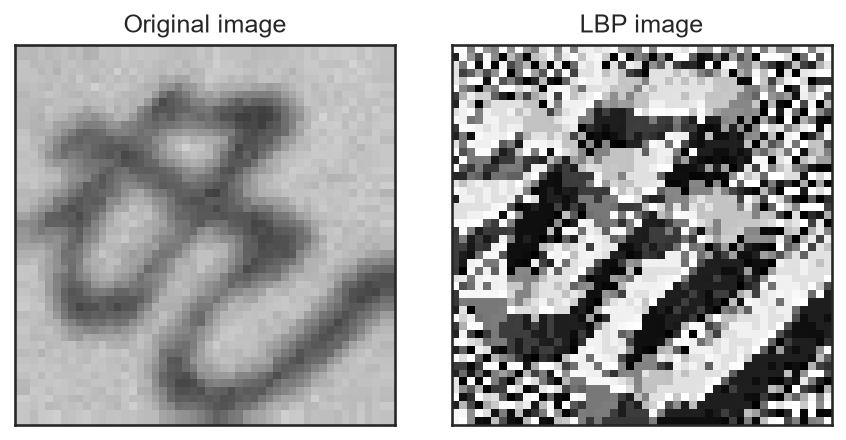

In [ ]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(6, 3))
gs = GridSpec(1, 2, figure=fig)

ax = plt.subplot(gs[0])
ax.imshow(img, cmap='gray', vmin=0, vmax=255)
ax.set(xticks=[], yticks=[], title='Original image')

ax = plt.subplot(gs[1])
ax.imshow(lbp_img, cmap='gray', vmin=0, vmax=255)
ax.set(xticks=[], yticks=[], title='LBP image')

plt.tight_layout()
plt.show()

LBPを用いることの利点は画像の**相対的な輝度の大小だけを見ている**点にあり、仮に画像の輝度が2倍になったりしても求まるLBPの値は全く変化しない。そのため、同じ対象を異なる光源下で計算した場合などに一貫した特徴を得られる。

ただし、このままLBP画像を扱うだけでは、得られる特徴ベクトルが画素の並びに強く依存することになるため、LBP画像をヒストグラム化することを考える。この際、画像全体をヒストグラム化するのではなく、画像をいくつかのパッチに分割して、パッチごとに256通りのLBP値の出現頻度をヒストグラムとしたものを一つにつなげて特徴ベクトルとして用いる。

なお、LBP値は8ビットの0と1のパターンを整数に読み替えたものであって大小関係に大きな意味はない。そのため、ヒストグラム化する際には、LBP値の範囲でビンをまとめることはせず、256通りの値をそのまま256個のビンとしてヒストグラムを作成する。

In [ ]:
ps = 8  # パッチサイズ
h, w = lbp_img.shape

lbp_patches = [lbp_img[y : y + ps, x : x + ps] for y in range(0, h, ps) for x in range(0, w, ps)]

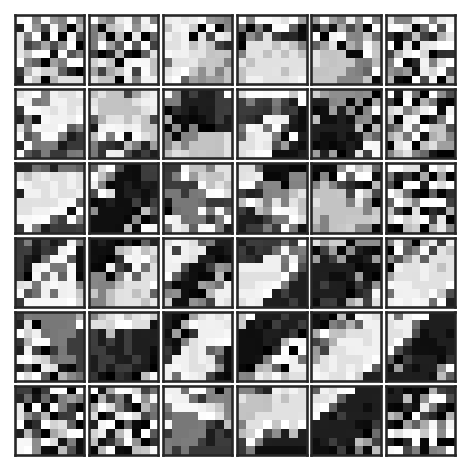

In [ ]:
fig = plt.figure(figsize=(3, 3))
gs = GridSpec(6, 6, figure=fig)
for i in range(36):
    ax = plt.subplot(gs[i])
    ax.imshow(lbp_patches[i], cmap='gray', vmin=0, vmax=255)
    ax.set(xticks=[], yticks=[])

plt.tight_layout(pad=0.2)
plt.show()

In [ ]:
feature = []

# パッチごとにLBPヒストグラムを計算
for patch in lbp_patches:
    hist = np.bincount(patch.flatten(), minlength=256) / patch.size
    feature.append(hist)

# 特徴ベクトルを一つにつなげる
feature = np.concatenate(feature, axis=0)

print(f'Feature shape: {feature.shape}')

Feature shape: (9216,)


これまでの議論をもとに、入力画像をLBP画像に変換するクラスを作成しよう。

scikit-learnを用いて、独自の特徴抽出の仕組みを作るためには`sklearn.base`に用意されているMixinクラスを用いる。今回は画像をLBP画像に「変換する」クラスを作成するので`TransformerMixin`を用いる。

`TransformerMixin`は`StandardScaler`や`PCA`のように`fit`と`transform`を抽象メソッドとして有しているので、新しいサブクラスを作るにはこれらのメソッドをオーバーライドすれば良い。

In [ ]:
from sklearn.base import TransformerMixin


class LBPFeature(TransformerMixin):
    """
    画像からLBP画像を計算するクラス
    """

    def __init__(self, image_size):
        self.image_size = image_size

    def fit(self, X, y=None):
        # fitは特に何もしなくて良い
        return self

    def transform(self, X, y=None):
        # 画像をパッチに区切る
        imgs = X.reshape((-1, self.image_size[1], self.image_size[0]))
        n_imgs, h, w = imgs.shape

        # 以下、リスト内包表記を用いるが配列のサイズに注意
        imgs = np.pad(imgs, ((0, 0), (1, 1), (1, 1)), mode='edge')
        patches = [imgs[:, y : y + 3, x : x + 3] for y in range(0, h) for x in range(0, w)]
        patches = np.array(patches, dtype='int32')  # (n_patches, n_imgs, ps, ps)
        patches = patches.transpose((1, 0, 2, 3))  # (n_imgs, n_patches, ps, ps)

        # LBPの計算
        # 上の図と同じ重み (右上から時計回りに2の0乗、2の1乗、...)を用いる
        mask = np.array([[64, 128, 1], [32, 0, 2], [16, 8, 4]], dtype='int32')
        mask = mask.reshape((1, 1, 3, 3))
        centers = patches[:, :, 1, 1].reshape((n_imgs, -1, 1, 1))
        binary = (patches >= centers).astype('int32')
        lbp_imgs = np.sum(binary * mask, axis=(2, 3))
        lbp_imgs = lbp_imgs.reshape((-1, h, w))

        # パッチごとにヒストグラムを計算
        ps = 8
        features = []
        for lbp_img in lbp_imgs:
            patches = [lbp_img[y : y + ps, x : x + ps] for y in range(0, h, ps) for x in range(0, w, ps)]
            histograms = [np.bincount(patch.flatten(), minlength=256) / patch.size for patch in patches]
            features.append(np.concatenate(histograms))

        return np.stack(features, axis=0)

In [ ]:
clf = make_pipeline(
    LBPFeature(image_size=(48, 48)),
    PCA(n_components=128),
    StandardScaler(),
    SGDClassifier(loss='hinge'),
)
clf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('lbpfeature', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](48,)","[ 0, 1, 2,...,45,46,47]"
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",128
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smalle

In [ ]:
# 識別精度の確認
acc_train = clf.score(X, y)
acc_test = clf.score(X_test, y_test)

In [ ]:
# | label: lbp_acc_train
result_df.loc[len(result_df), :] = ['LBP', acc_train, 'Train']
print('%.2f' % (acc_train * 100.0))

91.46


In [ ]:
# | label: lbp_acc_test
result_df.loc[len(result_df), :] = ['LBP', acc_test, 'Test']
print('%.2f' % (acc_test * 100.0))

78.02


**結果: Local Binary Patternの利用**

- 訓練時精度: ![](#lbp_acc_train)%
- 評価時精度: ![](#lbp_acc_test)%

結果から分かる通り、輝度に頑健な特徴を用い、さらにパッチに分割して特徴を取り出したことで、単純に画像を主成分分析する場合と比べて大きく精度が改善できた。

::::{admonition} 問
:class: question

中心画素の輝度が100、その周囲8画素の輝度が右上から時計回りに $(120, 80, 90, 130, 70, 110, 60, 140)$ であるとき、本文と同じ重みを用いたLBPの値を手計算で求めよ。

また、中心画素を含む9画素すべての輝度を2倍しても、あるいは一律に10を足しても、LBPの値が変わらないことを確かめ、その理由を述べよ。

::::

### Uniform LBP

元々のLBPが持つ回転に対して変化してしまう問題を解決した手法の一つに、Ojalaらが提案した**回転不変Uniform LBP** {cite}`ojala2002multiresolution` がある。

この手法の基本的なアイディアは、注目画素を中心に**円状に配置された点の輝度**を調べて、その輝度の大小関係のパターン (つまり, 0, 1の列)が回転したときに一致するものを同じ物であると見なすという部分にある。

より具体的には、円状に配置された0, 1の列を1周する間に何回0から1あるいは1から0への変化が起こるかを考える。例えば、12時方向を始点として反時計回りに `(0, 0, 1, 0, 1, 1, 1, 0)` というパターンが現れたとすると、0→1 / 1→0の遷移回数は4回である。

この手法では、遷移回数が0回のものと2回のもの (これらを**uniformなパターン**と呼ぶ)を特別視する。遷移の回数が0回、ということは、全ての要素が0か1かのいずれかで2通りが考えられる。また、遷移の回数が2回、ということは、0と1が両方含まれているものの、0と1が連続して現れているようなパターンで、これは要素の数が$N$個であれば、$N-1$通りのパターンが考えられる。

以上より、遷移の回数が0回のものと2回のものの総数は$N+1$個ある。これ以外のパターンは全て同じものであると見なすと、パターンの総数は$N+2$個である。

なお、文献で単に**Uniform LBP** (LBP$^{u2}$)と呼ぶ場合は、uniformなパターンを回転で同一視せず、そのまま区別することが多い。この場合、遷移回数が2回のパターンは「1の並び始める位置」と「1の個数」の組で決まるので$N(N-1)$通りとなり、パターンの総数は$N(N-1)+3$個になる。上で数えた$N+2$個は、これらをさらに回転で同一視した**回転不変Uniform LBP** (LBP$^{riu2}$)の場合の数である。

以下ではscikit-imageの`local_binary_pattern`を用いて、 $N = 36$ とした場合のLBP画像を見てみる。同メソッドの`method="uniform"`は回転不変版 (LBP$^{riu2}$)に対応しており、回転で同一視しない版を使いたい場合は`method="nri_uniform"`を指定する。

In [ ]:
from skimage.feature import local_binary_pattern

n_angles = 36
radius = 1.0
img = X[0].reshape((48, 48))
lbp = local_binary_pattern(img, n_angles, radius, method='uniform')

print(f'Uniform LBP has range from {lbp.min()} to {lbp.max()}.')

Uniform LBP has range from 0.0 to 37.0.


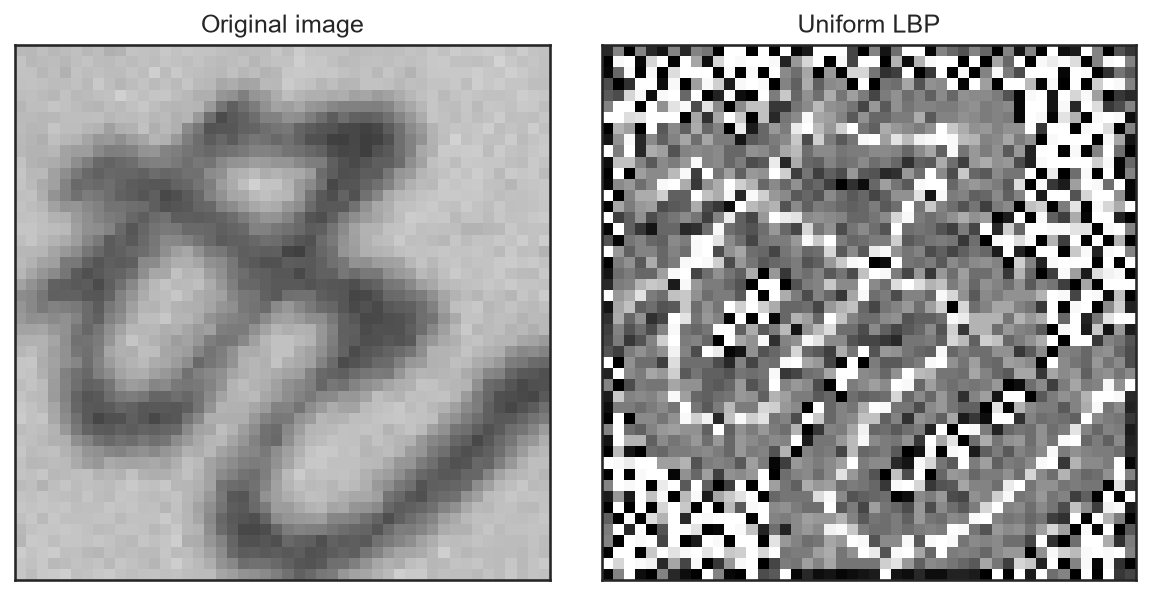

In [ ]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8, 4))
gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)

ax = plt.subplot(gs[0])
ax.imshow(img, cmap='gray', vmin=0, vmax=255)
ax.set(xticks=[], yticks=[], title='Original image')

ax = plt.subplot(gs[1])
ax.imshow(lbp, cmap='gray', vmin=0, vmax=n_angles + 1)
ax.set(xticks=[], yticks=[], title='Uniform LBP')

plt.tight_layout()
plt.show()

すると、上記の通り、輝度のパターン数は36 + 2 = 38通りになることが分かる (画像の輝度が0から37の38通りになっている)。

また、画像の見た目から、文字がある部分の周りが一様に近いグレーで表現されており、回転に対してある程度の不変性を持っていそうなことも確認できる。

ヒストグラムを作る際には、LBPの値域が$0$から$N+1$までの$N+2$通りであることに注意が必要である。ビンの境界を`np.arange(N + 3) - 0.5`のように半整数に置くことで、$N+2$個のビンが各LBP値に1対1で対応する。

では、このUniform LBPを用いて、再度SVMによる文字の分類を試してみる。Uniform LBPを使う場合、画像の拡大縮小への対応力を上げるために、**中心画素からどのくらい離れたところの画素をLBPの計算に使うか**を変えつつ、LBPを取得して、それらを結合した特徴量を使う。

In [ ]:
class UniformLBPFeature(TransformerMixin):
    """
    Uniform LBPを特徴として計算するクラス
    """

    def __init__(self, image_size):
        self.image_size = image_size

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        ps = 8  # ヒストグラム計算のためのパッチサイズ
        n_angles = [8, 12, 20]
        radii = [1.0, 2.5, 4.0]
        imgs = X.reshape((-1, self.image_size[1], self.image_size[0]))
        _, h, w = imgs.shape

        features = []
        for img in tqdm(imgs, desc='Uniform LBP'):
            lbp_feat = []
            for a, r in zip(n_angles, radii):
                # LBPの計算
                lbp_img = local_binary_pattern(img, a, r, method='uniform')

                # パッチごとにヒストグラムを計算
                patches = [lbp_img[y : y + ps, x : x + ps] for y in range(0, h, ps) for x in range(0, w, ps)]
                # 値域は0からa+1までのa+2通りなので、ビンの境界を半整数に置く
                histograms = [np.histogram(patch, bins=np.arange(a + 3) - 0.5, density=True)[0] for patch in patches]
                lbp_feat.extend(histograms)

            feature = np.concatenate(lbp_feat)
            features.append(feature)

        return np.stack(features, axis=0)

In [ ]:
clf = make_pipeline(
    UniformLBPFeature(image_size=(48, 48)),
    PCA(n_components=128),
    StandardScaler(),
    SGDClassifier(loss='hinge'),
)
clf.fit(X, y)

Uniform LBP:   0%|          | 0/7680 [00:00<?, ?it/s]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('uniformlbpfeature', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](48,)","[ 0, 1, 2,...,45,46,47]"
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",128
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the

In [ ]:
# 訓練時の識別精度の確認
acc_train = clf.score(X, y)
acc_test = clf.score(X_test, y_test)

Uniform LBP:   0%|          | 0/7680 [00:00<?, ?it/s]

Uniform LBP:   0%|          | 0/1920 [00:00<?, ?it/s]

In [ ]:
# | label: ulbp_acc_train
result_df.loc[len(result_df), :] = ['Uniform LBP', acc_train, 'Train']
print('%.2f' % (acc_train * 100.0))

88.15


In [ ]:
# | label: ulbp_acc_test
result_df.loc[len(result_df), :] = ['Uniform LBP', acc_test, 'Test']
print('%.2f' % (acc_test * 100.0))

69.32


**結果: Uniform LBPの利用**

- 訓練時精度: ![](#ulbp_acc_train)%
- 評価時精度: ![](#ulbp_acc_test)%

Uniform LBPの結果と前述のLBPの結果を比較すると、有意には精度が上昇していない。一因として、LBP特徴を用いる時点で画像をパッチに分割して特徴を取得していたために、ある程度、文字の回転に頑健な特徴となっていたということが考えられる。

Uniform LBPは回転に対して一貫した特徴を与える一方で、画像をヒストグラム化した場合には、単純なLBP画像と比べて得られる特徴が似通ってしまったという可能性も考えられる。

::::{admonition} 問
:class: question

LBPとUniform LBPについて、文字の画像の輝度を増減したり、画像を回転させたときに、パッチごとに抽出されるヒストグラム特徴がどのように変化するかを調べ、LBPとUniform LBPの精度の違いについて考察せよ。

::::

::::{admonition} 問
:class: question

8近傍のLBPが取り得るパターンは全部で $2^8 = 256$ 通りある。このうち、0と1の遷移回数がちょうど2回であるものが $8 \times 7 = 56$ 通りであることを、「1が並び始める位置」と「1の個数」の選び方に着目して説明せよ。

さらに、遷移回数が0回のもの2通りと、非uniformなパターンをまとめた1通りを加えると、scikit-imageの`method="nri_uniform"`が返す値が59通りになることを、実際に`local_binary_pattern`を実行して確かめよ。

::::

## Histogram of Oriented Gradient (HOG)

Histogram of Oriented Gradient (HOG)が広く知られるようになったのは2005年のことで、コンピュータ・ビジョンの国際会議であるCVPRで発表された論文{cite}`dalal2005histograms`がきっかけとなっている。

特にHOGは人物の全身といった特定の物体を見つける性能に優れており、一般物体認識や物体追跡等の多数の応用が生まれた。

HOGは画像全体で計算した勾配情報をパッチごとに集計することで計算する。今回用いるひらがな画像は48×48の大きさなので、これを8×8のパッチに区切ってみる。

In [ ]:
ps = 8  # パッチのサイズ
img = X[0].reshape((48, 48))
h, w = img.shape
patches = [img[y : y + ps, x : x + ps] for y in range(0, h, ps) for x in range(0, w, ps)]

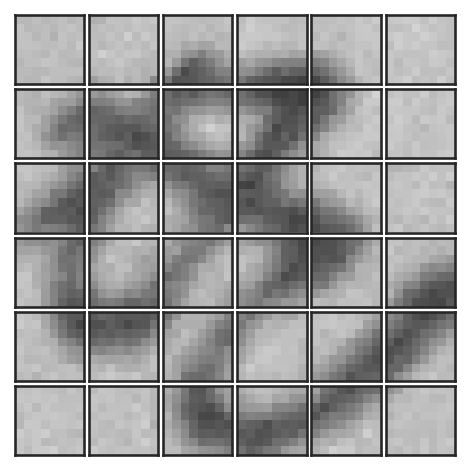

In [ ]:
fig = plt.figure(figsize=(3, 3))
gs = GridSpec(6, 6, figure=fig)

for i in range(6):
    for j in range(6):
        ax = plt.subplot(gs[i, j])
        ax.imshow(patches[i * 6 + j], cmap='gray', vmin=0, vmax=255, interpolation='none')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(pad=0.2)
plt.show()

次に、この各画像に対して、勾配強度と勾配方向を画素ごとに計算する。以下の実装では、x方向の勾配$d_x$とy方向の勾配$d_y$をSobelフィルタを使って求め、勾配強度$g$と勾配方向$\theta$を以下のように定義する。

$$
\begin{align}
    g &= \sqrt{ d_x^2 + d_y^2 } \\
    \theta &= \text{arctan} \frac{|d_y|}{d_x}
\end{align}
$$

なお、今回は向きのない方向 (= orientation, 0°から180°)を求めるため、上記の$\theta$の式において$d_y$に絶対値がかかっていることに注意すること。

また、`cv2.Sobel`の第2引数には出力画像のビット深度を指定するが、ここで`cv2.CV_8U`を指定すると、負の勾配が全て0に飽和してしまい、明るい領域から暗い領域へ向かうエッジが完全に失われる。例えば、暗い背景に明るい正方形が置かれた画像に対して縦方向のSobelフィルタをかけると、正方形の下端にあたる行の値は次のようになる。

```text
CV_32F: [0, 0, -255, -765, -1020, -765, -255, 0, 0]
CV_8U : [0, 0,    0,    0,     0,    0,    0, 0, 0]
```

符号付きの値を保持するため、以下では`cv2.CV_32F`を指定している。

実装では $\arctan$ の代わりに `np.arctan2` を用いる。 `np.arctan2(y, x)` は $d_x$ の符号まで考慮して角度を返すため、 $d_y \geq 0$ の下では$0°$から $180°$ までの範囲が得られる。一方、NumPyの `np.arctan` は引数を1つしか取らない関数で、第2引数は計算結果の出力先 (`out`) として解釈されてしまうため、 $d_x$ が無視されて角度が $0°$ から $90°$ の範囲にしか収まらなくなる。

また、 $d_y = 0$ かつ $d_x < 0$ のときには $\theta$ がちょうど $180°$ になり、ビンの番号が範囲外になるので、番号を `n_angles` で割ったあまりを取ることで巡回させている。

今、各パッチは8×8の大きさなので、勾配強度と勾配方向がそれぞれ64個ずつ求まる。求まった勾配方向をいくつかの方向に量子化 (今回は20°刻みで9方向)し、ヒストグラムを作成する。

この際、各画素の方向に対応するビンには**勾配強度を加算**して、ヒストグラムを計算する。なお、以下の計算では、勾配の方向を単純に量子化してビンの番号を決めるのではなく、隣接する2つのビンに線形補間で寄与を分配している。

In [ ]:
n_angles = 9  # 角度の量子化数

# エッジの抽出を最初に行う
dx = cv2.Sobel(img, cv2.CV_32F, 1, 0)
dy = cv2.Sobel(img, cv2.CV_32F, 0, 1)

# 勾配強度と角度を計算
g = np.sqrt(dx * dx + dy * dy)
theta = 180.0 * np.arctan2(np.abs(dy), dx) / np.pi

# 隣接する角度にヒストグラムの寄与を分配する
bin_width = 180.0 / n_angles
bin_val = theta / bin_width - 0.5
bin_lo = np.floor(bin_val).astype('int32')
w_hi = bin_val - bin_lo
w_lo = 1.0 - w_hi
bin_lo = bin_lo % n_angles
bin_hi = (bin_lo + 1) % n_angles

# 実際のヒストグラムを作成
histograms = []
for iy in range(0, h, ps):
    for ix in range(0, w, ps):
        lo_p = bin_lo[iy : iy + ps, ix : ix + ps].flatten()
        hi_p = bin_hi[iy : iy + ps, ix : ix + ps].flatten()
        w_lo_p = w_lo[iy : iy + ps, ix : ix + ps].flatten()
        w_hi_p = w_hi[iy : iy + ps, ix : ix + ps].flatten()
        g_p = g[iy : iy + ps, ix : ix + ps].flatten()
        hist = np.bincount(lo_p, weights=g_p * w_lo_p, minlength=n_angles)
        hist += np.bincount(hi_p, weights=g_p * w_hi_p, minlength=n_angles)
        histograms.append(hist)

histograms = np.stack(histograms, axis=0)

print(f'{len(histograms):d} histograms with {histograms.shape[1]:d} bins are obtained!')

36 histograms with 9 bins are obtained!


これにより6×6=36個のヒストグラムが求まった。ここで注意したいのは、これらのヒストグラムは勾配強度で計算されており、**場所によって、ヒストグラムのスケールが異なる**という点である。

そこで、HOGでは、この6×6=36個のパッチを3×3のブロックごとに走査し、そのブロック内で連結したヒストグラムを正規化して用いる。今、勾配方向は9つに離散化されており、ブロック内のパッチが3×3=9個なので、1ブロックが持つヒストグラムの次元は9×9=81次元である。この81次元ベクトルをノルムが1になるように正規化しておく。

なお、HOGでは、L2-Hysと呼ばれる正規化手法を用いることが多い。L2-Hysでは、まずベクトルをノルムが1になるように正規化し、その後、大きな成分を一定の値にクリップしてから、再度ノルムが1になるように正規化する。以下の実装ではクリップの閾値を0.2に設定している。

最終的に、81次元のヒストグラムが複数 (今回の場合は(6-3+1)×(6-3+1)=16個)求まるので、これらを連結して、画像の特徴量として用いる。

In [ ]:
bs = 3  # ブロックサイズ
histograms = histograms.reshape((6, 6, -1))  # 6x6のパッチ

# ブロックの取り出し
blocks = np.array([histograms[i : i + bs, j : j + bs] for i in range(6 - bs + 1) for j in range(6 - bs + 1)])
hog = blocks.reshape((-1, n_angles * bs * bs))

# ブロックごとのヒストグラムのノルムが1となるように正規化
hog = hog / (np.sqrt(np.sum(hog * hog, axis=1, keepdims=True)) + 1.0e-8)

# L2-Hys: 大きすぎる成分を0.2にクリップしてから再度正規化
hog = np.clip(hog, 0.0, 0.2)
hog = hog / (np.sqrt(np.sum(hog * hog, axis=1, keepdims=True)) + 1.0e-8)

hog = hog.flatten()

これらの処理をまとめて特徴量抽出のクラスを作成すると次のようになる。

In [ ]:
class HOGFeature(TransformerMixin):
    def __init__(self, image_size, patch_size=8, n_angles=9, block_size=3):
        self.image_size = image_size
        self.patch_size = patch_size
        self.n_angles = n_angles
        self.block_size = block_size

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        ps = self.patch_size
        bs = self.block_size
        n_angles = self.n_angles
        imgs = X.reshape((-1, *self.image_size))

        _, h, w = imgs.shape
        ph = h // ps  # 垂直方向のパッチ数
        pw = w // ps  # 水平方向のパッチ数

        features = []
        for img in imgs:
            # エッジの抽出を最初に行う
            dx = cv2.Sobel(img, cv2.CV_32F, 1, 0)
            dy = cv2.Sobel(img, cv2.CV_32F, 0, 1)

            # 勾配強度と角度を計算
            g = np.sqrt(dx * dx + dy * dy)
            theta = 180.0 * np.arctan2(np.abs(dy), dx) / np.pi

            # 隣接する角度にヒストグラムの寄与を分配する
            bin_width = 180.0 / n_angles
            bin_val = theta / bin_width - 0.5
            bin_lo = np.floor(bin_val).astype('int32')
            w_hi = bin_val - bin_lo
            w_lo = 1.0 - w_hi
            bin_lo = bin_lo % n_angles
            bin_hi = (bin_lo + 1) % n_angles

            # 実際のヒストグラムを作成
            histograms = []
            for iy in range(0, h, ps):
                for ix in range(0, w, ps):
                    lo_p = bin_lo[iy : iy + ps, ix : ix + ps].flatten()
                    hi_p = bin_hi[iy : iy + ps, ix : ix + ps].flatten()
                    w_lo_p = w_lo[iy : iy + ps, ix : ix + ps].flatten()
                    w_hi_p = w_hi[iy : iy + ps, ix : ix + ps].flatten()
                    g_p = g[iy : iy + ps, ix : ix + ps].flatten()
                    hist = np.bincount(lo_p, weights=g_p * w_lo_p, minlength=n_angles)
                    hist += np.bincount(hi_p, weights=g_p * w_hi_p, minlength=n_angles)
                    histograms.append(hist)

            histograms = np.stack(histograms, axis=0)
            histograms = histograms.reshape((ph, pw, -1))

            # ブロックごとにヒストグラムを正規化
            blocks = np.array(
                [histograms[i : i + bs, j : j + bs] for i in range(ph - bs + 1) for j in range(pw - bs + 1)]
            )
            hog = blocks.reshape((-1, n_angles * bs * bs))
            hog = hog / (np.sqrt(np.sum(hog * hog, axis=1, keepdims=True)) + 1.0e-8)

            hog = np.clip(hog, 0.0, 0.2)
            hog = hog / (np.sqrt(np.sum(hog * hog, axis=1, keepdims=True)) + 1.0e-8)

            hog = hog.flatten()
            features.append(hog)

        return np.stack(features, axis=0)

計算されたHOGを用いて、再度SVMを用いた分類を試してみる。

In [ ]:
clf = make_pipeline(
    HOGFeature(image_size=(48, 48)),
    PCA(n_components=128),
    StandardScaler(),
    SGDClassifier(loss='hinge'),
)
clf.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('hogfeature', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](48,)","[ 0, 1, 2,...,45,46,47]"
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",128
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smalle

In [ ]:
# 訓練時の識別精度の確認
acc_train = clf.score(X, y)
acc_test = clf.score(X_test, y_test)

In [ ]:
# | label: hog_acc_train
result_df.loc[len(result_df), :] = ['HOG', acc_train, 'Train']
print('%.2f' % (acc_train * 100.0))

94.65


In [ ]:
# | label: hog_acc_test
result_df.loc[len(result_df), :] = ['HOG', acc_test, 'Test']
print('%.2f' % (acc_test * 100.0))

80.16


**結果: Histogram of Oriented Gradientの利用**

- 訓練時精度: ![](#hog_acc_train)%
- 評価時精度: ![](#hog_acc_test)%

HOGは、画素の単純な大小を特徴化するLBPと比較して、勾配強度をヒストグラム化するという点で背景等のノイズに頑健な手法になっている。実際、今回の文字認識でも、LBPと比べて評価時の精度が大きく改善している。文字画像では輪郭線の向きが文字の識別に直結するため、勾配方向のヒストグラムという表現が有効に働いたと考えられる。

::::{admonition} 問
:class: question

48×48の画像をセルサイズ8×8、ブロックサイズ3×3、勾配方向9方向でHOG化したとき、最終的な特徴ベクトルの次元が $16 \times 81 = 1296$ 次元になることを確かめよ。

また、画像全体の輝度を2倍したとき、ブロック正規化を行う前と後とで、各ブロックのヒストグラムがどのように変化するかを$L^2$ノルムを計算して比べ、正規化が照明の変化に対して果たす役割を説明せよ。

::::

## Bag of Visual Words

ここまでの特徴量は、画素の情報を元にして何らかのヒストグラムを得る、という方法であったが、続いては、画像に内在する画像の構造としての特徴を疎に抽出し、その特徴の集合をヒストグラム化する手法である**Bag of Visual Words** (BoVW, Bag of Featuresとも呼ばれる)について見ていく。


BoVWは、自然言語処理分野の**Bag of Words**から着想を得たもので、元のBag of Wordsは辞書に登録された各単語が文書の中に何回登場するかをヒストグラムとして表わした物である。

これに対してBag of Visual Wordsは、画像データセットから抽出された疎な特徴量の集合を単語の集まりだと見なす。ただし、画像から得られる特徴量は通常連続的であるため、特徴量をあらかじめクラスタ分割しておき、各特徴が属するクラスタを単語、クラスタの集まりを辞書と見なすことでBag of Wordsと同様の処理を可能にする。

以下では、画像に対する疎な特徴量の代表格である**Scale-Invariant Feature Transform** (SIFT)について、BoVWによる画像認識を試みる。

### Scale-Invariant Feature Transform (SIFT)

Scale-Invariant Feature Transform (SIFT)は、深層学習以前の画像認識における金字塔的な技術で、2000年前後にLoweによって提案された{cite}`lowe1999object`, {cite}`lowe2004distinctive`。SIFTは画像の中に映り込む物体のスケールや回転に対して不変な特徴量を与えることができる。

SIFT特徴量の抽出処理は、少々複雑だが、大まかに分けて

- 特徴点の抽出
- 特徴点に対する特徴量の計算

の二つの処理に分けられる。

#### 特徴点の抽出

**特徴点の抽出**に置いては、Difference of Gaussian (DoG)というフィルタを用いて、特徴点のスケールを計算する。DoGは二つの異なる$\sigma_1$, $\sigma_2$ (ただし$\sigma_1 < \sigma_2$とする)を用いて、

$$
\text{DoG}(I) = G_{\sigma_1} \otimes I - G_{\sigma_2} \otimes I
$$

のように書ける。ただし$G_\sigma$は$\sigma$を標準偏差のパラメータとするGauss関数とする。例えば、以下のような画像になる。

In [ ]:
img = cv2.resize(X[0].reshape((48, 48)), (256, 256))
img = (img / 255.0).astype('float32')
B1 = cv2.GaussianBlur(img, None, sigmaX=2.0)
B2 = cv2.GaussianBlur(img, None, sigmaX=4.0)
DoG = B1 - B2

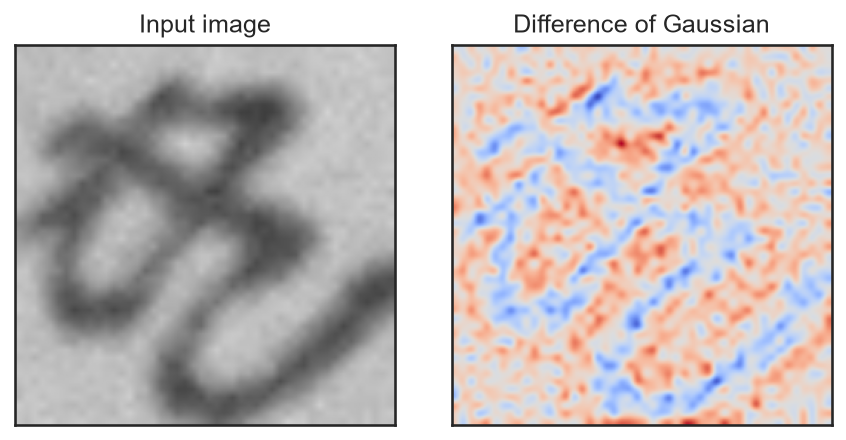

In [ ]:
fig = plt.figure(figsize=(6, 3))
gs = GridSpec(1, 2, figure=fig)
ax = plt.subplot(gs[0])
ax.imshow(img, cmap='gray', vmin=0.0, vmax=1.0)
ax.set(title='Input image', xticks=[], yticks=[])
ax = plt.subplot(gs[1])
ax.imshow(DoG, cmap='coolwarm')
ax.set(title='Difference of Gaussian', xticks=[], yticks=[])
plt.tight_layout()
plt.show()

DoGの抽出を初期のパラメータ$\sigma$とスケールパラメータ$k$を用いて、$k^n\sigma$と$k^{n+1}\sigma$の間で$n=0, 1, 2, ...$の順で計算をしていく。この計算の過程でDoGの値が極値を取っていたら、そこをキーポイントの候補点として選ぶ。

選ばれた候補点が実際に特徴点になるかどうかは、DoG値が極値を取るスケールにおいて、DoG画像$D$のその画素における勾配情報を参考にして決定する。具体的には、画像$D$から有限差分を用いて、ヘッセ行列

$$
\mathbf{H} = \begin{bmatrix}
    D_{xx} & D_{xy} \\
    D_{yx} & D_{yy} 
\end{bmatrix}
$$

を計算し、$\mathbf{H}$のトレースと行列式の比、

$$
\rho = \frac{(\text{tr} \mathbf{H})^2}{\text{det}\mathbf{H}}
$$ (eq:ratio-tr-det)

の値が一定の閾値$t$以下であれば、その候補特徴点を実際の特徴点として採用する。行列$\mathbf{H}$の固有値を$\lambda_1$, $\lambda_2$ (ただし$\lambda_1 > \lambda_2$とする)のとき、トレースと行列式は、それぞれ$\lambda_1 + \lambda_2$, $\lambda_1 \lambda_2$と表せるので、大きい方の固有値と小さい方の固有値の比を$r = \lambda_1 / \lambda_2$と置けば、{eq}`eq:ratio-tr-det`は、

$$
\rho = \frac{\left( \lambda_1 + \lambda_2 \right)^2}{\lambda_1 \lambda_2} = \frac{\left( \frac{\lambda_1}{\lambda_2} + 1 \right)^2}{\frac{\lambda_1}{\lambda_2}} = \frac{(r + 1)^2}{r}
$$

のように書き直せる。原論文では、$r = 10$を用いて、閾値$t$を

$$
t = \frac{(r + 1)^2}{r}
$$

のように定義している。この式は$t = r + 2 + 1 / r$と書き直せるので、$t$は$r = 1$のときに最小値$4$を取り、$r$が大きい範囲では以下のグラフのようにほぼ線形に増加する。

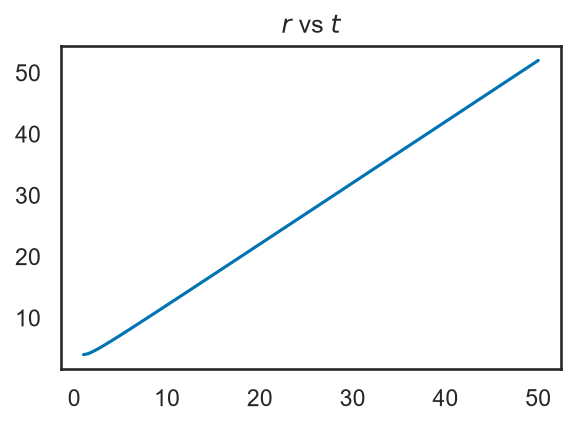

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))
r = np.linspace(1.0, 50.0, 100, endpoint=True)
t = (r + 1) ** 2 / r
ax.plot(r, t)
ax.set(title='$r$ vs $t$')
plt.tight_layout()
plt.show()

以上の処理を、直感的に述べれば、前半のDoGの処理は画像中の勾配がある箇所を検出し、さらに、その**勾配がどの程度の鮮鋭度を持つのかをスケールとして定量化**しようとしている。

後半の処理は、その盛り上がりが**どの方向にも同じように尖っているか**を見ている。エッジの上では、エッジに沿う方向の曲率が小さく、エッジと直交する方向の曲率が大きいため、ヘッセ行列の2つの固有値は大きく偏る。$r = 10$とした場合に{eq}`eq:ratio-tr-det`が$t$より小さい、ということは、即ち**ヘッセ行列の2つの固有値の比が一定以下** (10:1以下)であること、言い換えればエッジ上の点を候補から除くことを意味している。

なお、この$r$の値は以下のOpenCVのコードでは`edgeThreshold`という変数に対応する。もし、各画像から検出される特徴点が少なすぎるようであれば、この値を上げると、固有値の比がより大きい(=よりエッジに近い)特徴点も残されるようになる。

また、詳細は割愛するが、各特徴点には、勾配方向も同時に計算される。これは特徴点周りの画素に対して計算された勾配方向のヒストグラムの中で、いくつかの支配的な方向を特徴点に与えるものである。従って、各特徴点には2つ以上の勾配方向が割り当てられる可能性がある。

では、実際にOpenCVを用いて画像からSIFT特徴点と特徴量を計算する。以下では、特徴量の抽出結果を分かりやすくするために、48×48画素の画像を256×256画素にリサイズして特徴量を計算している。

In [ ]:
# 画像のリサイズ
img = X[0].reshape((48, 48)).copy()
img = cv2.resize(img, (256, 256))

# 特徴量抽出器の準備
sift = cv2.SIFT.create()

# 特徴点の検出
keypoints = sift.detect(img)

前述の通り、SIFT特徴点の検出では、位置、スケール、勾配方向が計算されるので、それらを`cv2.drawKeypoints`で可視化してみる。

In [ ]:
# 特徴点の描画 (画像に書き込みをするだけで表示はしない)
img_sift = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)

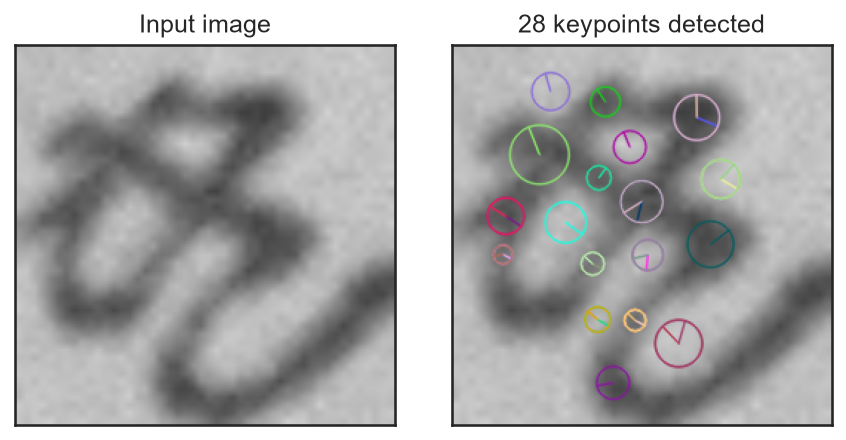

In [ ]:
fig = plt.figure(figsize=(6, 3))
gs = GridSpec(1, 2, figure=fig)
ax = plt.subplot(gs[0])
ax.imshow(img, cmap='gray', vmin=0, vmax=255)
ax.set(title='Input image', xticks=[], yticks=[])
ax = plt.subplot(gs[1])
ax.imshow(img_sift)
ax.set(
    title=f'{len(keypoints):d} keypoints detected',
    xticks=[],
    yticks=[],
)
plt.tight_layout()
plt.show()

画像中では、円の中心が特徴点の位置を、円の大きさが特徴点のスケールを、そして円の中心から弧に向かって伸びる線分が勾配方向をそれぞれ表わしている。この際、文字の輪郭線のぼけ具合と円の大きさに相関があり、なおかつ勾配方向が輪郭線とおよそ直交する方向となっていることに注目してほしい。また、特徴点の中には2つ以上の勾配方向を持つものが存在することにも注目してほしい。

::::{admonition} 問
:class: question

$\rho = (r + 1)^2 / r$ が $r \geq 1$ の範囲で単調増加し、$r = 1$ で最小値 $4$ を取ることを微分により示せ。

また、SIFTの特徴点の判定が $\rho \leq t$ という形になっている理由を、ヘッセ行列の2つの固有値が画像上でどのような形状に対応するかという観点から説明せよ。

::::

#### 特徴量の計算

特徴量の計算には、特徴点の計算で得られたスケールと方向を用いる。特徴量の計算には4×4のグリッドを用いるのだが、このグリッドの大きさを特徴点のスケールに応じて拡大縮小し、また勾配方向に応じてグリッドの向きを変更する。

このグリッドは上記の特徴点の可視化に現れる特徴点のスケールを表わす円に外接するように配置される。この円の大きさは、より具体的には極大のDoG値が検出された時に用いたGauss関数の$\sigma$の大きさに対応している。

グリッドの姿勢が計算できたら、4×4=16個のグリッドのそれぞれについて、特徴点の勾配方向ヒストグラムを45°刻みの8方向について計算する。この8個のビンの値を16個分連結することで、SIFT特徴量としての128次元ベクトルが得られる。

では、先ほど求めた特徴点に対して、OpenCVを用いて特徴量(記述子=descriptorとも言う)を計算する。

In [ ]:
# 特徴量の計算
_, features = sift.compute(img, keypoints)
print(f'{features.shape[0]:d} features with {features.shape[1]:d} dimensions')

28 features with 128 dimensions


このように特徴量 (`features`)は「特徴点の数」×「特徴量の次元=128」で与えられることが確認できる。なお、特徴点の抽出と特徴量の計算は`sift.detectAndCompute`を用いることで同時に行うこともできる。

::::{admonition} 問
:class: question

SIFT特徴量がスケールや画像の回転に対して頑健であるのは何故か。その計算方法に基づき説明せよ。

::::

:::{admonition} 技術と特許
:class: note

新しい技術を開発して「特許」を取得すると、その技術の詳細を明細書として公開する代わりに、その技術に関わる権利を得ることができる。この特許は、一見、他の会社が当該の技術を使う障壁を上げており、技術の進歩にとってはマイナスな一面もある。

その一方、特許が取られていたがために、その技術を回避する目的で技術が進歩することもある。先に紹介したSIFTは2000年に出願、2004年に成立した特許によって保護されており、出願から20年後の2020年3月に失効した (OpenCVでもこれを受けて、バージョン4.4以降はSIFTが標準のモジュールに移されている)。この特許の存在もあって、SIFTに代わる技術としてSpeeded-Up Robust Features (SURF) {cite}`bay2006surf`をはじめとする多くの特徴量が提案された (SURFにも特許があり、OpenCVでは長らく`opencv_contrib`の非フリーモジュールに置かれてきた)。

このような例は他の分野でも、たびたび見られるもので、CT画像から物体の表面形状を抽出するMarching Cubes法も、その特許権を回避する目的で、ほとんど同等なMarching Tetrahedra法が開発されたりした。このように、物事には表と裏とがあるのが常である。

:::

### 特徴量のクラスタリング

BoVWを計算するためには、訓練データに含まれる全ての画像について、特徴量を計算し、それをクラスタリングする必要がある。以下のコードでは、48×48という比較的小さな画像を扱うために`edgeThreshold`を調整して、検出される特徴点の数を増やしている。

In [ ]:
extractor = cv2.SIFT.create(edgeThreshold=32, contrastThreshold=0.0)

features = []
for x in tqdm(X, desc='Extract SIFT'):
    img = x.reshape((48, 48))
    keypoints, feature = extractor.detectAndCompute(img, None)
    assert len(keypoints) > 0, 'No keypoints detected!'
    features.append(feature)

Extract SIFT:   0%|          | 0/7680 [00:00<?, ?it/s]

In [ ]:
all_features = np.concatenate(features, axis=0)
print(f'SIFT: {len(all_features):d} keypoints ({len(all_features) / len(X):.1f}pts per image)')

SIFT: 237347 keypoints (30.9pts per image)


特徴量が得られたら、これをk平均法 (k-means法)によってクラスタリングする。今回は特徴量の数が20万を超えるため、scikit-learnの`MiniBatchKMeans`を用いて、ミニバッチによる近似的なクラスタリングを行う。

In [ ]:
from sklearn.cluster import MiniBatchKMeans

cb_size = 128  # コードブックのサイズ
cluster = MiniBatchKMeans(n_clusters=cb_size)
cluster.fit(all_features)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",128
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism <lower-level-parallelism-with-openmp>`on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


In [ ]:
feature = features[0]
cb_ids = cluster.predict(feature)
bovw_feat = np.bincount(cb_ids, minlength=cb_size)

In [ ]:
class BoVWFeature(TransformerMixin):
    def __init__(self, image_size, n_clusters=128):
        self.image_size = image_size
        self.extractor = cv2.SIFT.create(edgeThreshold=32, contrastThreshold=0.0)
        self.n_clusters = n_clusters
        self.cluster = MiniBatchKMeans(n_clusters=n_clusters)

    def fit(self, X, y=None):
        features = []

        # 各画像ごとにSIFT特徴を計算
        for x in tqdm(X, desc='Extract SIFT'):
            img = x.reshape(self.image_size)
            keypoints, feature = self.extractor.detectAndCompute(img, None)
            assert len(keypoints) > 0, 'No keypoints detected!'
            features.append(feature)

        # k-meansクラスタリング
        features = np.concatenate(features, axis=0)
        self.cluster.fit(features)

        return self

    def transform(self, X, y=None):
        features = []
        for x in tqdm(X, desc='BoVW encoding'):
            # SIFT特徴の抽出
            img = x.reshape(self.image_size)
            keypoints, feature = self.extractor.detectAndCompute(img, None)
            assert len(keypoints) > 0, 'No keypoints detected!'

            # 各特徴がどのクラスタに属するかを計算
            cb_ids = self.cluster.predict(feature)
            bovw_feat = np.bincount(cb_ids, minlength=self.n_clusters)
            bovw_feat = bovw_feat / np.sum(np.abs(bovw_feat))
            features.append(bovw_feat)

        return np.stack(features, axis=0)

In [ ]:
clf = make_pipeline(
    BoVWFeature(image_size=(48, 48), n_clusters=128),
    StandardScaler(),
    SGDClassifier(loss='hinge'),
)
clf.fit(X, y)

Extract SIFT:   0%|          | 0/7680 [00:00<?, ?it/s]

BoVW encoding:   0%|          | 0/7680 [00:00<?, ?it/s]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('bovwfeature', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](48,)","[ 0, 1, 2,...,45,46,47]"
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](128,)","[0. ,0.01,0.01,...,0.01,0.01,0.01]"


In [ ]:
# 識別精度の確認
acc_train = clf.score(X, y)
acc_test = clf.score(X_test, y_test)

BoVW encoding:   0%|          | 0/7680 [00:00<?, ?it/s]

BoVW encoding:   0%|          | 0/1920 [00:00<?, ?it/s]

In [ ]:
# | label: bovw_acc_train
result_df.loc[len(result_df), :] = ['BoVW', acc_train, 'Train']
print('%.2f' % (acc_train * 100.0))

86.50


In [ ]:
# | label: bovw_acc_test
result_df.loc[len(result_df), :] = ['BoVW', acc_test, 'Test']
print('%.2f' % (acc_test * 100.0))

72.81


**結果: Bag of Visual Wordsの利用**

- 訓練時精度: ![](#bovw_acc_train)%
- 評価時精度: ![](#bovw_acc_test)%

### 発展: Gauss混合モデルを用いた改良

上記の例では、離散的に特徴量をクラスタ分割して、**最も近いクラスタ**に対して、各特量を割り当てることでヒストグラムを作成した。ただし、複数のクラスタの境界に特徴量が存在している可能性もあるため、その情報を捨てて、一番近いクラスタに特徴量を割り当てるのは、あまり適切とは言えない。

そこで、クラスタリングを用いる代わりに、特徴量の分布をGauss混合モデルによって近似しておき、各Gauss分布への寄与 (小数で表わされる)を画像の特徴ベクトルとして与えることを考える。

**Gauss混合モデル**とは、複数のGauss分布を和が1となるような正の重みによって重み付けたものであり、確率密度関数$P(\mathbf{x} | \boldsymbol\Theta)$, $\mathbf{x} \in \mathbb{R}^D$が以下の形で書ける。

$$
P(\mathbf{x} | \boldsymbol\Theta) = \sum_{k=1}^K \frac{\alpha_k}{(2 \pi)^{D / 2} \left| \boldsymbol\Sigma_k \right|^{1/2}} \exp \left( - \frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_k)^\top \boldsymbol\Sigma_k^{-1}  (\mathbf{x} - \boldsymbol{\mu}_k) \right)
$$ (eq:gaussian-mixture)

のように書ける。この式で$\boldsymbol\Theta$はパラメータの集合 $\{ \alpha_k, \boldsymbol\mu_k, \boldsymbol\Sigma_k : k = 1, \ldots, K \}$を表わし、$\alpha_k \in [0, 1]$, $\boldsymbol\mu_k \in \mathbb{R}^D$, $\boldsymbol\Sigma_k \in \mathbb{R}^{D \times D}$は、それぞれ$k$番目のGauss分布に対する混合率、分布中心、共分散行列を表わす。

ガウス混合分布を用いると、とある特徴量$\mathbf{x}$が$k$個のGauss分布のそれぞれにどの程度の寄与率$\gamma_k(\mathbf{x})$を持つかを以下のように計算できる。

$$
\gamma_k(\mathbf{x}) = \frac{\alpha_k}{(2\pi)^{D/2} \left| \boldsymbol\Sigma_k \right|^{1/2}}\frac{\exp \left( - \frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_k)^\top \boldsymbol\Sigma_k^{-1}  (\mathbf{x} - \boldsymbol\mu_k) \right) }{P(\mathbf{x})}
$$ (eq:membership)

これにより、特徴量$\mathbf{x}$に対する、特徴表現として、

$$
\boldsymbol\gamma(\mathbf{x}) = \left( \gamma_1(\mathbf{x}), \ldots, \gamma_K(\mathbf{x}) \right)^\top
$$

が得られる。これを画像に含まれる特徴量の集合$\mathcal{X} = \{ \mathbf{x}_i : i = 1, \ldots, N \}$に対して計算し、その平均値を画像の特徴ベクトルとする。

$$
\mathbf{f}(\mathcal{X}) = \frac{1}{N} \sum_{i=1}^N \boldsymbol\gamma(\mathbf{x}_i)
$$

以下の実装では、これに加えて$\boldsymbol\gamma(\mathbf{x}_i)$の標準偏差も連結し、$2K$次元の特徴ベクトルとしている。平均だけでは「どの分布にどれだけ属するか」しか分からないのに対し、標準偏差を加えることで「その割合が画像内の特徴量ごとにどの程度ばらついているか」も特徴に含められる。

ここまでの議論を踏まえて、BoVWを改善したコードが以下になる。ここではscikit-learnの`GaussianMixture`を用いてGauss混合モデルのフィッティングを行う。ただし、Gauss混合モデルのフィッティングは、かなり時間のかかる処理であるため、共分散行列を対角行列に制限する`covariance_type='diag'`を指定し、さらにEMアルゴリズムの反復回数を`max_iter=10`に抑えて計算時間を短縮している。

In [ ]:
from sklearn.mixture import GaussianMixture

cb_size = 32  # コードブックのサイズ
gmm = GaussianMixture(n_components=cb_size, covariance_type='diag', max_iter=10)
gmm.fit(all_features)

,"n_components n_components: int, default=1The number of mixture components.",32
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'diag'
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",10
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


In [ ]:
class BoVWGMMFeature(TransformerMixin):
    def __init__(self, image_size, n_clusters=32):
        self.image_size = image_size
        self.extractor = cv2.SIFT.create(edgeThreshold=32, contrastThreshold=0.0)
        self.gmm = GaussianMixture(n_components=n_clusters, covariance_type='diag', max_iter=10)

    def fit(self, X, y=None):
        features = []

        # 各画像ごとにSIFT特徴を計算
        for x in tqdm(X, desc='SIFT extraction'):
            img = x.reshape(self.image_size)
            keypoints, feature = self.extractor.detectAndCompute(img, None)
            assert len(keypoints) > 0, 'No keypoints detected!'
            features.append(feature)

        # ガウス混合モデルの計算
        features = np.concatenate(features, axis=0)
        self.gmm.fit(features)

        return self

    def transform(self, X, y=None):
        features = []
        for x in tqdm(X, desc='BoVW encoding'):
            # SIFT特徴の抽出
            img = x.reshape(self.image_size)
            keypoints, feature = self.extractor.detectAndCompute(img, None)
            assert len(keypoints) > 0, 'No keypoints detected!'

            # 各特徴が各クラスタに属する確率を計算
            proba = self.gmm.predict_proba(feature)
            mu = np.mean(proba, axis=0)
            std = np.std(proba, axis=0)
            feat = np.concatenate([mu, std])
            features.append(feat)

        return np.stack(features, axis=0)

In [ ]:
clf = make_pipeline(
    BoVWGMMFeature(image_size=(48, 48), n_clusters=128),
    StandardScaler(),
    SGDClassifier(loss='hinge'),
)
clf.fit(X, y)

SIFT extraction:   0%|          | 0/7680 [00:00<?, ?it/s]

BoVW encoding:   0%|          | 0/7680 [00:00<?, ?it/s]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('bovwgmmfeature', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](48,)","[ 0, 1, 2,...,45,46,47]"
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](256,)","[0.01,0.02,0.01,...,0.04,0.04,0.03]"


In [ ]:
# 識別精度の確認
acc_train = clf.score(X, y)
acc_test = clf.score(X_test, y_test)

BoVW encoding:   0%|          | 0/7680 [00:00<?, ?it/s]

BoVW encoding:   0%|          | 0/1920 [00:00<?, ?it/s]

In [ ]:
# | label: bovwg_acc_train
result_df.loc[len(result_df), :] = ['GMM-BoVW', acc_train, 'Train']
print('%.2f' % (acc_train * 100.0))

87.40


In [ ]:
# | label: bovwg_acc_test
result_df.loc[len(result_df), :] = ['GMM-BoVW', acc_test, 'Test']
print('%.2f' % (acc_test * 100.0))

71.82


**結果: GMM-BoVW**

- 訓練時精度: ![](#bovwg_acc_train)%
- 評価時精度: ![](#bovwg_acc_test)%

::::{admonition} 問
:class: question

k平均法やGauss混合モデルは、教師なし学習法の一種で、そのクラスタや分布の数はユーザが必要に応じて与える必要がある。これらを自動的に決めるための指標として赤池情報基準(AIC = Akaike Information Criterion)やBayes情報基準 (=Bayes Information Criterion)がある。それぞれがどのようなものか調べよ。

::::

### Fisherベクトルの利用

BoVWの改良としてFisherベクトルを利用する手法は2007年にPerronninらによって提案された{cite}`perronnin2007fisher`。Fisherベクトルは、統計学等でも用いられるFisher情報量に基づく特徴表現である。とある確率密度分布が、パラメータ (母数)$\boldsymbol\Theta$を与えたときの$\mathbf{x} \in \mathcal{X}$の条件付き密度 $P(\mathbf{x} | \boldsymbol\Theta)$ として与えられる場合を考える。

#### 発展: Fisherベクトルの導出

Fisher情報量を求めるに当たり、Fisherベクトル$V(\mathbf{x}; \boldsymbol\Theta)$を

$$
V(\mathbf{x}; \boldsymbol\Theta) = \nabla_{\boldsymbol\Theta} \log P(\mathbf{x} | \boldsymbol\Theta)
$$

のように表わす。なお、微分と積分の順序交換が許される正則条件の下では、$\mathbf{x}$を$P(\mathbf{x} | \boldsymbol\Theta)$に従って取ったときのFisherベクトルの平均はゼロベクトルになる。

Fisher情報量は上記のFisherベクトルの分散として定義される。この際、Fisherベクトルの平均が$\mathbf{0}$であることを用いると、分散共分散行列は次の式で与えられる。

$$
\mathbf{I}(\boldsymbol\Theta) = \mathbb{E}_{\mathbf{x} \sim P(\cdot | \boldsymbol\Theta)} \left[ \nabla_{\boldsymbol\Theta} \log P(\mathbf{x} | \boldsymbol\Theta) \left( \nabla_{\boldsymbol\Theta} \log P(\mathbf{x} | \boldsymbol\Theta) \right)^\top \right]
$$

さて、ここで、$P(\mathbf{x} | \boldsymbol\Theta)$が{eq}`eq:gaussian-mixture`のガウス混合分布で与えられる場合を考える。以後、計算を簡単にするために、共分散行列は対角成分を$\boldsymbol\sigma_k$とする対角行列であるとする。

とあるパラメータ$\theta$に関する$\log P(\mathbf{x} | \boldsymbol\Theta)$の微分は、

$$
\frac{\partial \log P(\mathbf{x}| \boldsymbol\Theta)}{\partial \theta} = \frac{1}{P(\mathbf{x} | \boldsymbol\Theta)} \frac{\partial P}{\partial\theta}
$$

と書けることは言うまでもない。また、$P(\mathbf{x} | \boldsymbol\Theta)$の$\pi_k$, $\mu_{k,d}$, $\sigma_{k,d}$に関する偏微分はそれぞれ以下のように書ける。

$$
\begin{align}
\frac{\partial P(\mathbf{x} | \boldsymbol\Theta)}{\partial \alpha_k}
&= \frac{\exp \left( -\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_k)^\top \boldsymbol\Sigma_k^{-1}  (\mathbf{x} - \boldsymbol{\mu}_k) \right)}{(2\pi)^{D/2} | \boldsymbol\Sigma_k |^{1/2}} = \mathcal{N}(\mathbf{x} | \boldsymbol\mu_{k}, \boldsymbol\sigma_k) \\
%
\frac{\partial P(\mathbf{x} | \boldsymbol\Theta)}{\partial \mu_{k,d}}
&= \alpha_k \left[ \frac{x_d - \mu_{k,d}}{\sigma_{k,d}^2} \right] \mathcal{N}(\mathbf{x} | \boldsymbol\mu_{k}, \boldsymbol\sigma_k) \\
%
\frac{\partial P(\mathbf{x} | \boldsymbol\Theta)}{\partial \sigma_{k,d}}
&= \alpha_k \left[ \frac{(x_d - \mu_{k,d})^2}{\sigma_{k,d}^3} - \frac{1}{\sigma_{k,d}} \right] \mathcal{N}(\mathbf{x} | \boldsymbol\mu_{k}, \boldsymbol\sigma_k)
\end{align}
$$

したがって、{eq}`eq:membership`の寄与率$\gamma_k$を用いると、フィッシャーベクトルの各次元は以下のように書き直せる。

$$
\begin{align}
\frac{\partial \log P(\mathbf{x}| \boldsymbol\Theta)}{\partial \alpha_k}
&= \frac{\gamma_k(\mathbf{x})}{\alpha_k} \\
%
\frac{\partial \log P(\mathbf{x}| \boldsymbol\Theta)}{\partial \mu_{k,d}}
&= \gamma_k(\mathbf{x}) \left[ \frac{x_d - \mu_{k,d}}{\sigma_{k,d}^2} \right] \\
%
\frac{\partial \log P(\mathbf{x}| \boldsymbol\Theta)}{\partial \sigma_{k,d}}
&= \gamma_k(\mathbf{x}) \left[ \frac{(x_d - \mu_{k,d})^2}{\sigma_{k,d}^3}  - \frac{1}{\sigma_{k,d}} \right]
\end{align}
$$

ここで、$\mathcal{X} = \{ \mathbf{x}_1, \ldots, \mathbf{x}_N \}$として、これらの同時分布$P(\mathcal{X} | \boldsymbol\Theta)$を考える。$\mathbf{x}_i$は互いに独立なサンプルであるので、

$$
P(\mathcal{X} | \boldsymbol\Theta) = \prod_{i=1}^N P(\mathbf{x}_i | \boldsymbol\Theta)
$$

故に、この対数尤度$L(\mathcal{X} | \boldsymbol\Theta)$は、

$$
L(\mathcal{X} | \boldsymbol\Theta) = \sum_{i=1}^N \log P(\mathbf{x}_i | \boldsymbol\Theta)
$$

となることが分かる。この尤度関数のパラメータに関する偏微分からFisherベクトルを求めると、以下のようになる。

$$
\frac{\partial L(\mathcal{X} | \boldsymbol\Theta)}{\partial \alpha_k}
= \sum_{i=1}^N \left[ \frac{\gamma_k(\mathbf{x}_i)}{\alpha_k} - \frac{\gamma_1(\mathbf{x}_i)}{\alpha_1}  \right] \quad \text{for} ~ k \geq 2  $$ (eq:deriv-alpha)

$$
\frac{\partial L(\mathcal{X} | \boldsymbol\Theta)}{\partial \mu_{k,d}}
= \sum_{i=1}^N \gamma_k(\mathbf{x}_i) \left[ \frac{x_{i,d} - \mu_{k,d}}{\sigma_{k,d}^2} \right] \\
$$ (eq:deriv-mu)

$$
\frac{\partial L(\mathcal{X} | \boldsymbol\Theta)}{\partial \sigma_{k,d}}
= \sum_{i=1}^N \gamma_k(\mathbf{x}_i) \left[ \frac{(x_{i,d} - \mu_{k,d})^2}{\sigma_{k,d}^3} - \frac{1}{\sigma_{k,d}} \right]
$$ (eq:deriv-sigma)

ただし、{eq}`eq:deriv-alpha`では、$\sum_{k} \alpha_k = 1$であることを用いて、自由度を一つ減らしてある。

ここまでの式から、Fisherベクトルの次元は$\alpha_k$に関する成分が$K - 1$次元、$\mu_{k,d}$に関する成分が$DK$次元、$\sigma_{k,d}$に関する成分が$DK$次元あるので、合計で$(2D + 1) K - 1$次元となる。

#### 発展: Fisherベクトルの意味

上記の通り、Fisherベクトルはとあるデータ集合$\mathcal{X}$を近似的に表わすGauss混合モデルについて、そのパラメータ$\boldsymbol\Theta$に関する勾配を要素に持つ。この意味を考えてみよう。

とある確率密度関数をサンプルにフィッティングする問題を考えるとき、その確率密度関数の対数尤度が最大になるようにパラメータを最適化する。従って、**Fisherベクトルの各要素は、そのパラメータの変化が、どの程度尤度に影響を与えるかを示している**、と言い換えられる。

この影響の大きさの期待値を表わしているのがFisher情報量であり、各パラメータに関するFisher情報量はFisherベクトルの各要素の二乗平均により与えられる。Fisher情報量は、推定するパラメータを正しく推定するために、どの程度十分な情報(=サンプル)が得られているかを示しており、**情報量が大きければ大きいほど、サンプルから求まるパラメータの最尤推定量が真の値に近づくことが期待される** (推定量の分散とFisher情報量の逆数の関係はCramér-Raoの不等式で与えられる)。

従って、とある画像に対して計算されるFisherベクトルは、 **その画像(から得られた特徴量の集合)が、画像全体(のGauss混合分布)から見て、どのような意外性を持つか、と言い換えても良い** 。その画像が全体のGauss混合分布にとって十分尤もらしいものであれば、尤度の勾配から定まるFisherベクトルの要素は小さな値(特に意外ではない)を取り、そうでなければ、大きな値(意外である)を取る、という訳である。

ただし、画像の分類の観点から言えば、Fisherベクトルがどのような意味を持つか、ということよりも、それ自体が、単なるクラスタへの所属や、Gauss混合モデル以上に画像を上手く表現できるような特徴を与えるということに価値がある。

実際、{eq}`eq:deriv-alpha`は画像が含む特徴量に関して、どの分布にどのくらいの割合で属するかを表わす0次統計量であるのに対し、{eq}`eq:deriv-mu`ならびに{eq}`eq:deriv-sigma`は、それぞれ1次統計量、2次統計量を表している。

実装上は、この Fisher 情報量を実際に用いる。Fisher カーネルは $K(\mathcal{X}_a, \mathcal{X}_b) = \mathbf{g}_a^\top \mathbf{F}^{-1} \mathbf{g}_b$ で定義されるので、$\mathbf{F}^{-1/2} \mathbf{g}$ を特徴ベクトルとすれば、通常の内積 (すなわち線形SVM) で Fisher カーネルが計算できる。Perronnin と Dance は $\mathbf{F}$ を対角行列で近似しており、対数尤度を $N$ で割った平均を用いると、各 $\mathbf{x}$ がほぼ1つの成分 $k$ にだけ属するという仮定の下で、

$$
F_{\mu_{k,d}} \approx \mathbb{E}\left[ \gamma_k \frac{(x_d - \mu_{k,d})^2}{\sigma_{k,d}^4} \right] = \frac{\alpha_k}{\sigma_{k,d}^2}, \qquad
F_{\sigma_{k,d}} \approx \alpha_k \frac{\mathbb{E}[(z^2 - 1)^2]}{\sigma_{k,d}^2} = \frac{2\alpha_k}{\sigma_{k,d}^2}
$$

と近似できる ($z = (x_d - \mu_{k,d})/\sigma_{k,d}$ は標準正規分布に従い、$\mathbb{E}[z^4] = 3$ を用いた)。したがって $\mathbf{F}^{-1/2}$ を掛けることは、$\mu$ の成分に $\sigma_{k,d}/\sqrt{\alpha_k}$ を、$\sigma$ の成分に $\sigma_{k,d}/\sqrt{2\alpha_k}$ を掛けることに対応する。以下の実装ではこの正規化を行っている。なお $\alpha_k$ の成分については、本資料のパラメータ化では $\mathbf{F}$ が対角にならないため、$N$ で割るだけにとどめている。

#### Fisherベクトルを用いた画像分類

それでは、実際に全画像から取得したSIFT特徴量を用いて、各画像に対応するFisherベクトルを求めてみよう。Perronninらの元論文 {cite}`perronnin2007fisher`では、計算量を削減するために、得られたSIFT特徴量を主成分分析によって50次元に削減した後、Gauss混合モデルをフィッティングしてFisherベクトルを求めている。

なお、実装上の注意として、scikit-learnの`GaussianMixture`は`covariance_type='diag'`のとき、`covariances_`に**分散** $\sigma_{k,d}^2$ を格納する。{eq}`eq:deriv-mu`と{eq}`eq:deriv-sigma`の$\sigma_{k,d}$は標準偏差なので、平方根を取ってから式に代入する必要がある。

In [ ]:
# PCAの適用
pca = PCA(n_components=50)
all_sub_feats = pca.fit_transform(all_features)

# 次元削減結果に対してGMMを計算
sub_gmm = GaussianMixture(n_components=32, covariance_type='diag', max_iter=10)
sub_gmm.fit(all_sub_feats)

,"n_components n_components: int, default=1The number of mixture components.",32
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'diag'
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",10
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None


In [ ]:
feature = features[0]

sub_feat = pca.transform(feature)  # (N, D)
n_feat = sub_feat.shape[0]

gamma = sub_gmm.predict_proba(sub_feat)  # (N, K)
alpha = sub_gmm.weights_  # (K)
mu = sub_gmm.means_  # (K, D)
sigma = np.sqrt(sub_gmm.covariances_)  # (K, D) covariances_は分散なので平方根を取る

g_over_a = gamma / alpha
dLda = np.sum(g_over_a[:, 1:] - g_over_a[:, 0:1], axis=0)

diff = sub_feat[:, None, :] - mu[None, :, :]  # (N, K, D)
tmp0 = diff / (sigma[None, :, :] ** 2)  # (N, K, D)
dLdm = np.sum(gamma[:, :, None] * tmp0, axis=0)

tmp0 = diff**2 / (sigma[None, :, :] ** 3)
tmp1 = 1.0 / sigma[None, :, :]
dLds = np.sum(gamma[:, :, None] * (tmp0 - tmp1), axis=0)

# 正規化
dLda /= n_feat
dLdm /= n_feat
dLds /= n_feat

# Fisher情報量の対角近似を掛ける
dLdm = dLdm * sigma / np.sqrt(alpha)[:, None]
dLds = dLds * sigma / np.sqrt(2.0 * alpha)[:, None]

fisher_vector = np.concatenate([dLda, dLdm.reshape(-1), dLds.reshape(-1)])

In [ ]:
class FisherVectorFeature(TransformerMixin):
    def __init__(self, image_size, n_clusters=32):
        self.image_size = image_size
        self.extractor = cv2.SIFT.create(edgeThreshold=32, contrastThreshold=0.0)

        self.pca = PCA(n_components=50)
        self.gmm = GaussianMixture(
            n_components=n_clusters,
            covariance_type='diag',
            max_iter=10,
        )

    def fit(self, X, y=None):
        features = []

        # 各画像ごとにSIFT特徴を計算
        for x in tqdm(X, desc='SIFT extraction'):
            img = x.reshape(self.image_size)
            keypoints, feature = self.extractor.detectAndCompute(img, None)
            assert len(keypoints) > 0, 'No keypoints detected!'
            features.append(feature)

        # PCAを適用
        all_feats = np.concatenate(features)
        all_sub_feats = self.pca.fit_transform(all_feats)

        # GMMの計算
        self.gmm.fit(all_sub_feats)

        return self

    def transform(self, X, y=None):
        features = []
        for x in tqdm(X, desc='Fisher vector encoding'):
            # SIFT特徴の抽出
            img = x.reshape(self.image_size)
            keypoints, feature = self.extractor.detectAndCompute(img, None)
            assert len(keypoints) > 0, 'No keypoints detected!'

            # 次元削減
            sub_feat = self.pca.transform(feature)
            n_feat = sub_feat.shape[0]

            # Fisherベクトルの計算
            gamma = self.gmm.predict_proba(sub_feat)  # (N, K)
            alpha = self.gmm.weights_  # (K)
            mu = self.gmm.means_  # (K, D)
            sigma = np.sqrt(self.gmm.covariances_)  # (K, D) covariances_は分散なので平方根を取る

            g_over_a = gamma / alpha
            dLda = np.sum(g_over_a[:, 1:] - g_over_a[:, 0:1], axis=0)

            diff = sub_feat[:, None, :] - mu[None, :, :]  # (N, K, D)
            tmp0 = diff / (sigma[None, :, :] ** 2)  # (N, K, D)
            dLdm = np.sum(gamma[:, :, None] * tmp0, axis=0)

            tmp0 = diff**2 / (sigma[None, :, :] ** 3)
            tmp1 = 1.0 / sigma[None, :, :]
            dLds = np.sum(gamma[:, :, None] * (tmp0 - tmp1), axis=0)

            dLda /= n_feat
            dLdm /= n_feat
            dLds /= n_feat

            dLdm = dLdm * sigma / np.sqrt(alpha)[:, None]
            dLds = dLds * sigma / np.sqrt(2.0 * alpha)[:, None]

            fv = np.concatenate([dLda, dLdm.reshape(-1), dLds.reshape(-1)])
            features.append(fv)

        return np.stack(features, axis=0)

In [ ]:
clf = make_pipeline(
    FisherVectorFeature(image_size=(48, 48), n_clusters=128),
    StandardScaler(),
    SGDClassifier(loss='hinge'),
)
clf.fit(X, y)

SIFT extraction:   0%|          | 0/7680 [00:00<?, ?it/s]

Fisher vector encoding:   0%|          | 0/7680 [00:00<?, ?it/s]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('fishervectorfeature', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](48,)","[ 0, 1, 2,...,45,46,47]"
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](12927,)","[ 0.06,-0. ,-0.01,..., 0. , 0. , 0. ]"


In [ ]:
# 識別精度の確認
acc_train = clf.score(X, y)
acc_test = clf.score(X_test, y_test)

Fisher vector encoding:   0%|          | 0/7680 [00:00<?, ?it/s]

Fisher vector encoding:   0%|          | 0/1920 [00:00<?, ?it/s]

In [ ]:
# | label: fisher_acc_train
result_df.loc[len(result_df), :] = ['Fisher-BoVW', acc_train, 'Train']
print('%.2f' % (acc_train * 100.0))

100.00


In [ ]:
# | label: fisher_acc_test
result_df.loc[len(result_df), :] = ['Fisher-BoVW', acc_test, 'Test']
print('%.2f' % (acc_test * 100.0))

97.34


**結果: FisherベクトルによるBoVW**

- 訓練時精度: ![](#fisher_acc_train)%
- 評価時精度: ![](#fisher_acc_test)%

::::{admonition} 問
:class: question

Fisherベクトルの次元が $(2D + 1)K - 1$ 次元になることを、{eq}`eq:deriv-alpha`から{eq}`eq:deriv-sigma`までの3つの式がそれぞれ何次元の情報を持つかに着目して説明せよ。

また、{eq}`eq:membership`の寄与率が、任意の $\mathbf{x}$ に対して $\sum_{k=1}^K \gamma_k(\mathbf{x}) = 1$ を満たすことを示せ。

::::

## 手法の比較

ここまでの手法の訓練時、ならびにテスト時のスコアを比較してみよう。画像をそのまま入力した場合や、単に主成分分析で次元を落とした場合と比べると、LBP、HOG、BoVWといった特徴量を経由した手法はいずれも高いスコアを示している。中でも、Gauss混合モデルの尤度勾配までを特徴に取り込んだFisherベクトルは、他の手法を大きく引き離している。特徴量の設計次第で、同じ分類器・同じデータからでも引き出せる情報量が大きく変わることが分かる。

また、訓練時と評価時のスコアの差にも注目したい。この差が大きい手法は、訓練データに含まれる個々の画像の癖まで覚え込んでしまっている、すなわち過学習を起こしていることを意味する。

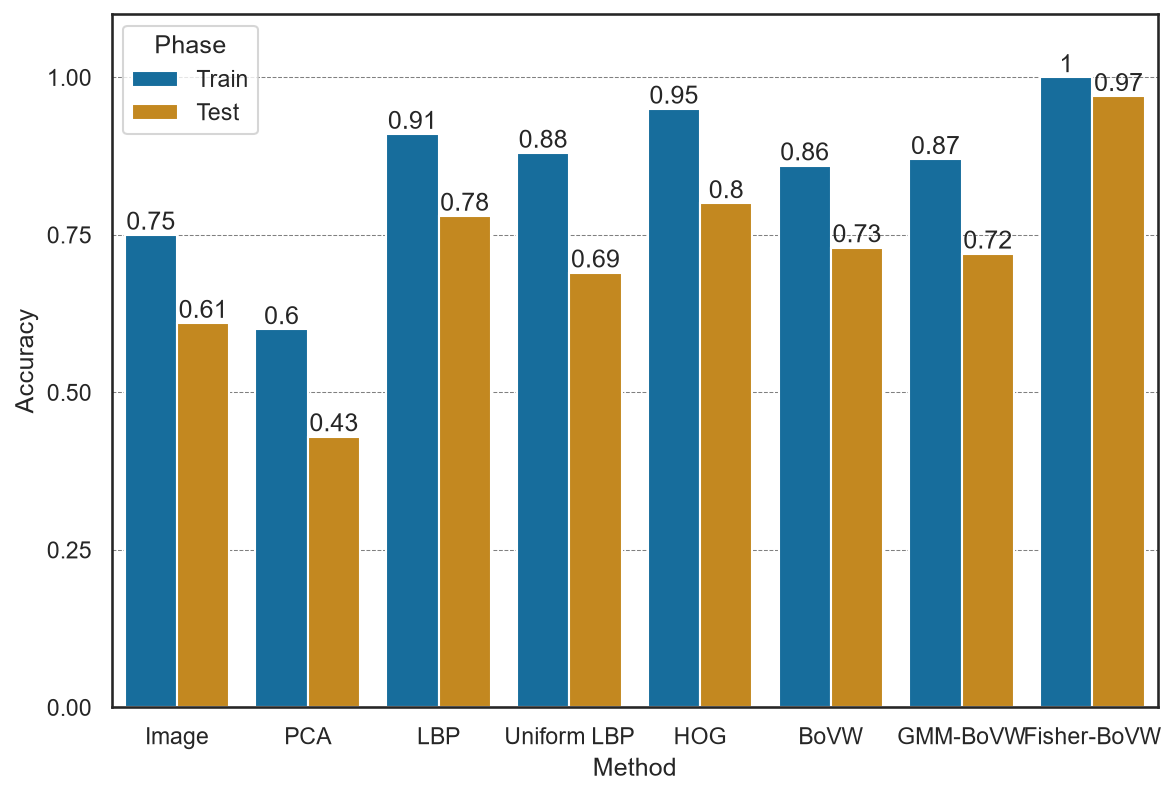

In [80]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x='Method',
    y='Accuracy',
    hue='Phase',
    data=result_df.round(2),
    err_kws={'linewidth': 0},
)

for i in ax.containers:
    ax.bar_label(i)

plt.yticks(np.linspace(0.0, 1.0, 5))
plt.ylim([0.0, 1.1])
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.5)
plt.show()

::::{admonition} 問
:class: question

BoVWの性能がSIFT以外の特徴量 (OpenCVにはORB {cite}`rublee2011orb` (=Oriented FAST and Rotated BRIEF)やKAZE {cite}`alcantarilla2012kaze` が実装されている)を使うと、どのように変化するかを調べよ。

::::

## 参考文献

```{bibliography}
:filter: docname in docnames
```